## 实验4 神经网络的正则化

### 读取图像形式的MNIST
划分为train/test  
对数据进行归一化，即0-1之间，数据要变成float类型  
把数据顺序打乱  
注：若训练慢，可以减少训练图像数量

In [5]:
import gzip
import os
import struct
import numpy as np

def load_mnist(path, kind='train'):
    """加载MNIST数据集"""
    labels_path = os.path.join(path, f'{kind}-labels-idx1-ubyte.gz')
    images_path = os.path.join(path, f'{kind}-images-idx3-ubyte.gz')

    with gzip.open(labels_path, 'rb') as lbpath:
        struct.unpack('>II', lbpath.read(8))
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8)

    with gzip.open(images_path, 'rb') as imgpath:
        struct.unpack('>IIII', imgpath.read(16))
        images = np.frombuffer(imgpath.read(), dtype=np.uint8).reshape(len(labels), 784)

    return images, labels



# 数据集划分
def data_split(images, labels, ratio):
    
    total_len = images.shape[0]
    offset = int(total_len * ratio)
    
    val_img = images[:offset][:]
    val_lb = labels[:offset]
    
    train_img = images[offset:][:]
    train_lb = labels[offset:]
    
    return train_img, train_lb, val_img, val_lb    

# 读取训练集和测试集数据
[images, labels] = load_mnist('../MNIST', kind='train')
[test_img, test_lb] = load_mnist('../MNIST',kind='test')
train_img, train_lb, val_img, val_lb = data_split(images, labels, 1/6)

train_img = train_img.astype(np.float32) / 255.0
val_img = val_img.astype(np.float32) / 255.0
test_img = test_img.astype(np.float32) / 255.0

# 对标签进行热编码
one_hot_train_lb = np.eye(10)[train_lb]
one_hot_val_lb = np.eye(10)[val_lb]
one_hot_test_lb= np.eye(10)[test_lb]

# 打印查看数据集格式
print('训练集图像格式为:', train_img.shape, '训练集标签格式为:', train_lb.shape,'热编码训练集标签格式为:', one_hot_train_lb.shape)
print('验证集图像格式为:', val_img.shape, '验证集标签格式为:', val_lb.shape,'热编码验证集标签格式为:', one_hot_val_lb.shape)
print('测试集图像格式为:', test_img.shape, '测试集标签格式为:', test_lb.shape,'热编码测试集标签格式为:', one_hot_test_lb.shape)

训练集图像格式为: (50000, 784) 训练集标签格式为: (50000,) 热编码训练集标签格式为: (50000, 10)
验证集图像格式为: (10000, 784) 验证集标签格式为: (10000,) 热编码验证集标签格式为: (10000, 10)
测试集图像格式为: (10000, 784) 测试集标签格式为: (10000,) 热编码测试集标签格式为: (10000, 10)


### 题目1：定义并训练一个由3层线性分类器组成的神经网络
使用Pytorch定义网络  
L2损失函数   
中间层激活函数relu      
使用L2正则化项

In [6]:
import torch
from torch import nn
import torch.optim as optim

class LinearClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.W1 = nn.Linear(784, 256)
        self.W2 = nn.Linear(256, 128)
        self.W3 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.W1(x))
        x = self.relu(self.W2(x))
        x = self.W3(x)
        return x

model = LinearClassifier()
loss_fn = nn.MSELoss()

learning_rate = 0.01
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

print(model)

LinearClassifier(
  (W1): Linear(in_features=784, out_features=256, bias=True)
  (W2): Linear(in_features=256, out_features=128, bias=True)
  (W3): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


训练网络，给出测试精度

In [7]:
epoch = 20
batch_size = 100
batch_num = train_img.shape[0] // batch_size

loss_his1 = []
acc_his1 = []

model.train()

for i in range(epoch):
    mean_loss = 0
    acc = 0
    for j in range(batch_num):
        X = train_img[j*batch_size:(j+1)*batch_size,]
        y = one_hot_train_lb[j*batch_size:(j+1)*batch_size,:]

        X=torch.tensor(X, dtype=torch.float32)
        y=torch.tensor(y, dtype=torch.float32)

        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()

        mean_loss += loss.item()
        acc += (pred.argmax(1) == y.argmax(1)).type(torch.float).mean().item()

    mean_loss /= batch_num
    acc /= batch_num
    loss_his1.append(mean_loss)
    acc_his1.append(acc)

    print(f" Epoch: {i+1}, loss: {mean_loss:>8f},  Accuracy: {(100*acc):>0.1f}%")

 Epoch: 1, loss: 0.089368,  Accuracy: 31.6%
 Epoch: 2, loss: 0.079660,  Accuracy: 59.9%
 Epoch: 3, loss: 0.072475,  Accuracy: 68.2%
 Epoch: 4, loss: 0.065640,  Accuracy: 72.3%
 Epoch: 5, loss: 0.059986,  Accuracy: 74.8%
 Epoch: 6, loss: 0.055661,  Accuracy: 76.7%
 Epoch: 7, loss: 0.052372,  Accuracy: 78.2%
 Epoch: 8, loss: 0.049778,  Accuracy: 79.6%
 Epoch: 9, loss: 0.047648,  Accuracy: 80.7%
 Epoch: 10, loss: 0.045841,  Accuracy: 81.6%
 Epoch: 11, loss: 0.044259,  Accuracy: 82.4%
 Epoch: 12, loss: 0.042837,  Accuracy: 83.1%
 Epoch: 13, loss: 0.041534,  Accuracy: 83.7%
 Epoch: 14, loss: 0.040326,  Accuracy: 84.3%
 Epoch: 15, loss: 0.039194,  Accuracy: 84.9%
 Epoch: 16, loss: 0.038132,  Accuracy: 85.4%
 Epoch: 17, loss: 0.037130,  Accuracy: 85.9%
 Epoch: 18, loss: 0.036186,  Accuracy: 86.3%
 Epoch: 19, loss: 0.035296,  Accuracy: 86.7%
 Epoch: 20, loss: 0.034456,  Accuracy: 87.1%


#### 测试集与验证集

In [10]:
model.eval()
test_loss, test_acc = 0, 0
with torch.no_grad():
        X=torch.tensor(test_img, dtype=torch.float32)
        y=torch.tensor(one_hot_test_lb, dtype=torch.float32)
        pred = model(X)
        test_loss = loss_fn(pred, y).item()
        test_acc = (pred.argmax(1) == y.argmax(1)).type(torch.float).mean().item()
print(f"Test Accuracy: {(100*test_acc):>0.1f}%, Test loss: {test_loss:>8f} \n")

with torch.no_grad():
        X=torch.tensor(val_img, dtype=torch.float32)
        y=torch.tensor(one_hot_val_lb, dtype=torch.float32)
        pred = model(X)
        val_loss = loss_fn(pred, y).item()
        val_acc = (pred.argmax(1) == y.argmax(1)).type(torch.float).mean().item()
print(f"Val Accuracy: {(100*val_acc):>0.1f}%, Val loss: {val_loss:>8f} \n")


Test Accuracy: 88.0%, Test loss: 0.033044 

Val Accuracy: 87.4%, Val loss: 0.033529 



#### 绘制损失曲线和精确率曲线

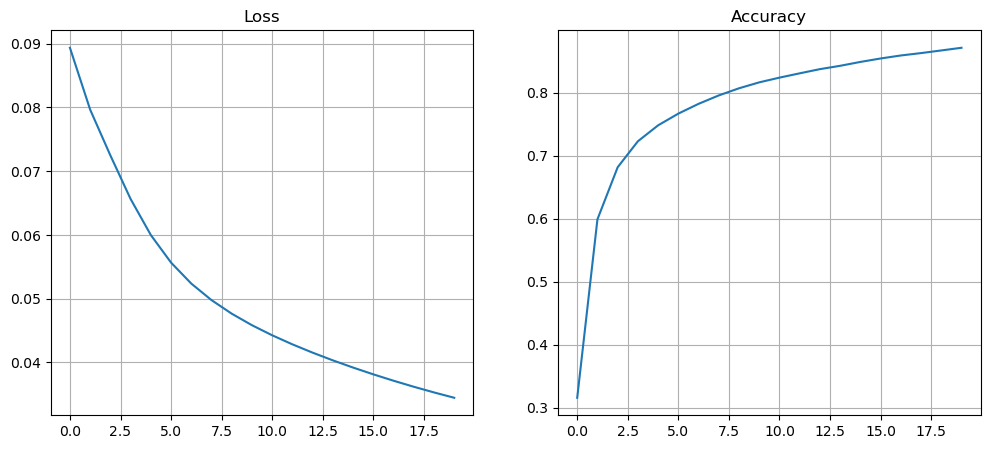

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_his1, label='Loss')
plt.title('Loss')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(acc_his1, label='Accuracy')
plt.title('Accuracy')
plt.grid()

plt.show()

### 题目2：参考PPT，添加dropout，再次训练、测试，对比分析dropout的作用


In [12]:
import torch
from torch import nn
import torch.optim as optim

class DropoutNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.W1 = nn.Linear(784, 256)
        self.W2 = nn.Linear(256, 128)
        self.W3 = nn.Linear(128, 10)

        self.dropout = nn.Dropout()
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.W1(x))
        x = self.dropout(x)
        x = self.relu(self.W2(x))
        x = self.dropout(x)
        x = self.W3(x)
        return x

dropout_model = DropoutNet()
loss_fn = nn.CrossEntropyLoss()

learning_rate = 0.01
optimizer = optim.SGD(dropout_model.parameters(), lr=learning_rate, weight_decay=1e-4)

print(dropout_model)

DropoutNet(
  (W1): Linear(in_features=784, out_features=256, bias=True)
  (W2): Linear(in_features=256, out_features=128, bias=True)
  (W3): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (relu): ReLU()
)


训练网络，给出测试精度

In [13]:
epoch = 20
batch_size = 100
batch_num = train_img.shape[0] // batch_size

loss_his2 = []
acc_his2 = []

dropout_model.train()

for i in range(epoch):
    mean_loss = 0
    acc = 0
    for j in range(batch_num):
        X = train_img[j*batch_size:(j+1)*batch_size,]
        y = one_hot_train_lb[j*batch_size:(j+1)*batch_size,:]

        X=torch.tensor(X, dtype=torch.float32)
        y=torch.tensor(y, dtype=torch.float32)

        optimizer.zero_grad()
        pred = dropout_model(X)
        loss = loss_fn(pred, y.argmax(1))

        loss.backward()
        optimizer.step()

        mean_loss += loss.item()
        acc += (pred.argmax(1) == y.argmax(1)).type(torch.float).mean().item()

    mean_loss /= batch_num
    acc /= batch_num
    loss_his2.append(mean_loss)
    acc_his2.append(acc)

    print(f" Epoch:{i+1}, loss: {mean_loss:>8f},  Accuracy: {(100*acc):>0.1f}%")

 Epoch:1, loss: 2.193416,  Accuracy: 31.6%
 Epoch:2, loss: 1.481582,  Accuracy: 57.7%
 Epoch:3, loss: 0.933874,  Accuracy: 71.0%
 Epoch:4, loss: 0.742920,  Accuracy: 77.1%
 Epoch:5, loss: 0.641058,  Accuracy: 80.5%
 Epoch:6, loss: 0.578994,  Accuracy: 82.8%
 Epoch:7, loss: 0.527587,  Accuracy: 84.4%
 Epoch:8, loss: 0.494170,  Accuracy: 85.7%
 Epoch:9, loss: 0.466375,  Accuracy: 86.3%
 Epoch:10, loss: 0.439539,  Accuracy: 87.3%
 Epoch:11, loss: 0.419764,  Accuracy: 87.9%
 Epoch:12, loss: 0.400773,  Accuracy: 88.5%
 Epoch:13, loss: 0.379770,  Accuracy: 88.9%
 Epoch:14, loss: 0.369751,  Accuracy: 89.3%
 Epoch:15, loss: 0.354589,  Accuracy: 89.8%
 Epoch:16, loss: 0.341656,  Accuracy: 90.1%
 Epoch:17, loss: 0.335784,  Accuracy: 90.4%
 Epoch:18, loss: 0.323159,  Accuracy: 90.7%
 Epoch:19, loss: 0.314263,  Accuracy: 91.1%
 Epoch:20, loss: 0.303522,  Accuracy: 91.4%


#### 测试集与验证集

In [14]:
dropout_model.eval()
test_loss, test_acc = 0, 0
with torch.no_grad():
        X=torch.tensor(test_img, dtype=torch.float32)
        y=torch.tensor(one_hot_test_lb, dtype=torch.float32)
        pred = dropout_model(X)
        test_loss = loss_fn(pred, y.argmax(1)).item()
        test_acc = (pred.argmax(1) == y.argmax(1)).type(torch.float).mean().item()
print(f"Test Accuracy: {(100*test_acc):>0.1f}%, Test Avg loss: {test_loss:>8f} \n")

with torch.no_grad():
        X=torch.tensor(val_img, dtype=torch.float32)
        y=torch.tensor(one_hot_val_lb, dtype=torch.float32)
        pred = dropout_model(X)
        val_loss = loss_fn(pred, y.argmax(1)).item()
        val_acc = (pred.argmax(1) == y.argmax(1)).type(torch.float).mean().item()
print(f"Val Accuracy: {(100*val_acc):>0.1f}%, Val Avg loss: {val_loss:>8f} \n")


Test Accuracy: 93.9%, Test Avg loss: 0.200164 

Val Accuracy: 94.1%, Val Avg loss: 0.207803 



#### 绘制损失曲线和精确率曲线

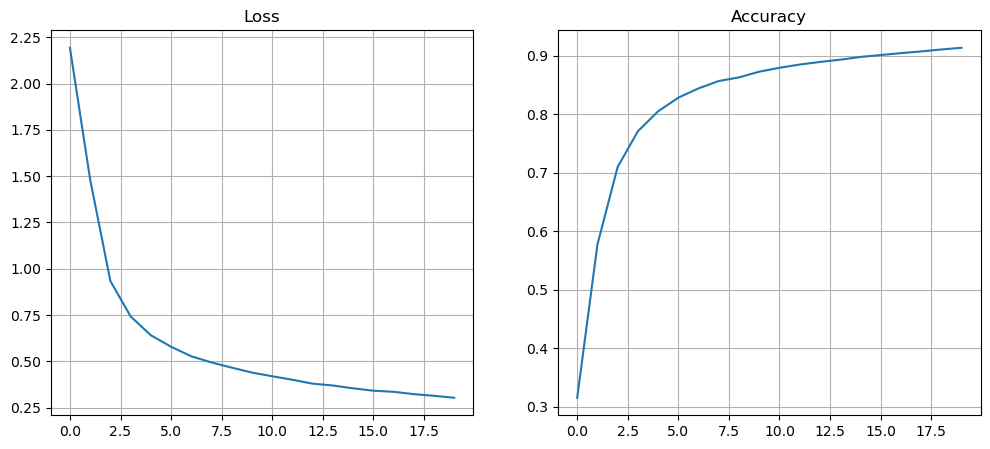

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_his2, label='Loss')
plt.title('Loss')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(acc_his2, label='Accuracy')
plt.title('Accuracy')
plt.grid()

plt.show()

### 题目3：参考PPT进行数据增强，再次训练、测试，对比分析数据增强的作用



In [16]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
from PIL import Image
import numpy as np
import torch

transform = transforms.Compose([
    transforms.RandomRotation(5),  # 随机旋转图像
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08)),  # 位置偏移
    transforms.ToTensor(),
    transforms.RandomErasing(
        p=0.1,
        scale=(0.02, 0.1),
        ratio=(0.3, 3.3),
        value=0.0,
    ),  # 轻微遮挡：随机擦除小块
])

learning_rate = 0.01
epoch = 20
batch_size = 100
batch_num = train_img.shape[0] // batch_size

train_images_numpy = train_img.reshape(-1, 28, 28)
train_labels_tensor = torch.tensor(one_hot_train_lb)

train_dataset = [(transform(Image.fromarray((image * 255).astype(np.uint8))), label) for image, label in zip(train_images_numpy, train_labels_tensor)]
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

model = LinearClassifier()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)
loss_his3 = []
acc_his3 = []

model.train()
for i in range(epoch):
    mean_loss = 0
    acc = 0
    for X, y in train_loader:
        X = X.float()
        
        optimizer.zero_grad()
        pred = model(X.view(X.size(0), -1))
        loss = loss_fn(pred, y.argmax(1))

        loss.backward()
        optimizer.step()

        mean_loss += loss.item()
        acc += (pred.argmax(1) == y.argmax(1)).type(torch.float).mean().item()

    mean_loss /= len(train_loader)
    acc /= len(train_loader)
    loss_his3.append(mean_loss)
    acc_his3.append(acc)

    print(f" Epoch: {i+1}, loss: {mean_loss:>8f},  Accuracy: {(100*acc):>0.1f}%")

 Epoch: 1, loss: 2.250882,  Accuracy: 27.3%
 Epoch: 2, loss: 1.888622,  Accuracy: 50.9%
 Epoch: 3, loss: 1.294331,  Accuracy: 61.7%
 Epoch: 4, loss: 1.028871,  Accuracy: 68.2%
 Epoch: 5, loss: 0.915645,  Accuracy: 72.0%
 Epoch: 6, loss: 0.840999,  Accuracy: 74.5%
 Epoch: 7, loss: 0.779951,  Accuracy: 76.5%
 Epoch: 8, loss: 0.726438,  Accuracy: 78.2%
 Epoch: 9, loss: 0.676398,  Accuracy: 79.9%
 Epoch: 10, loss: 0.629903,  Accuracy: 81.3%
 Epoch: 11, loss: 0.585367,  Accuracy: 82.8%
 Epoch: 12, loss: 0.543342,  Accuracy: 84.2%
 Epoch: 13, loss: 0.504384,  Accuracy: 85.2%
 Epoch: 14, loss: 0.468271,  Accuracy: 86.4%
 Epoch: 15, loss: 0.434654,  Accuracy: 87.4%
 Epoch: 16, loss: 0.404938,  Accuracy: 88.3%
 Epoch: 17, loss: 0.378125,  Accuracy: 89.1%
 Epoch: 18, loss: 0.353800,  Accuracy: 89.9%
 Epoch: 19, loss: 0.332752,  Accuracy: 90.5%
 Epoch: 20, loss: 0.314302,  Accuracy: 91.1%


#### 测试集与验证集

In [17]:
model.eval()
test_loss, test_acc = 0, 0
with torch.no_grad():
        X=torch.tensor(test_img, dtype=torch.float32)
        y=torch.tensor(one_hot_test_lb, dtype=torch.float32)
        pred = model(X)
        test_loss = loss_fn(pred, y.argmax(1)).item()
        test_acc = (pred.argmax(1) == y.argmax(1)).type(torch.float).mean().item()
print(f"Test Accuracy: {(100*test_acc):>0.1f}%, Test Avg loss: {test_loss:>8f} \n")

with torch.no_grad():
        X=torch.tensor(val_img, dtype=torch.float32)
        y=torch.tensor(one_hot_val_lb, dtype=torch.float32)
        pred = model(X)
        val_loss = loss_fn(pred, y.argmax(1)).item()
        val_acc = (pred.argmax(1) == y.argmax(1)).type(torch.float).mean().item()
print(f"Val Accuracy: {(100*val_acc):>0.1f}%, Val Avg loss: {val_loss:>8f} \n")

Test Accuracy: 94.8%, Test Avg loss: 0.188819 

Val Accuracy: 94.6%, Val Avg loss: 0.207207 



#### 绘制损失曲线和精确率曲线

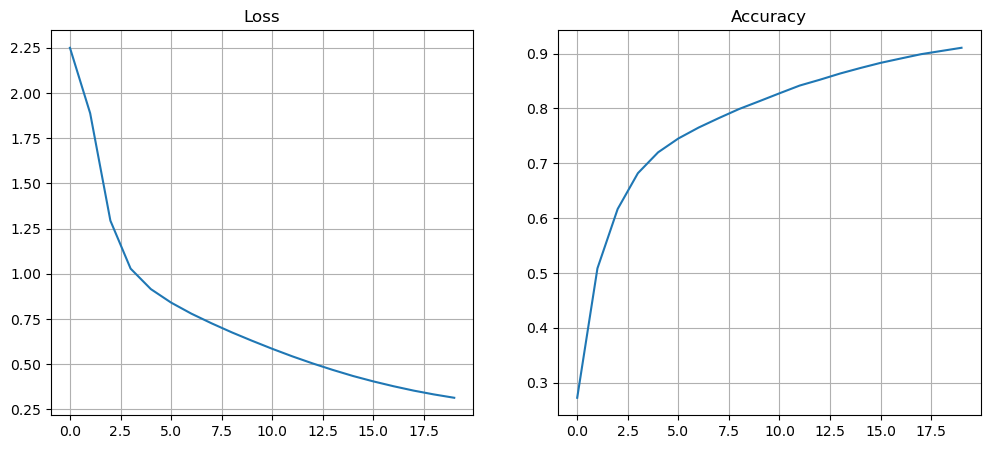

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_his3, label='Loss')
plt.title('Loss')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(acc_his3, label='Accuracy')
plt.title('Accuracy')
plt.grid()

plt.show()

## 训练过程分析
### **损失曲线观察：**
**题目1（线性分类器）：**
- Loss从0.089降到0.034，下降比较平稳，但下降速度逐渐变慢，可能进入瓶颈期   

**题目2（+Dropout）：**
- Loss从2.19降到0.30，下降更明显
- 初期Loss更高，因为Dropout让训练更难；最终Loss更低，说明模型学得更好  

**题目3（+数据增强）：**
- Loss从2.25降到0.31
- 数据增强增加了训练难度，但提高了泛化能力，测试集和验证集精确度更高   

### **精精确度曲线观察：**
- 三个模型的精确度都稳步上升
- 题目2和题目3的训练精确度稍低，但测试精确度更高
---
## 实验结果对比分析
### **测试集精确度对比：**
| 方法 | 测试精确度 | 验证精确度 |
|------|---------|---------|
| 基础网络 | 88.0% | 87.4% |
| +Dropout | 93.9% | 94.1% |
| +数据增强 | 94.8% | 94.6% |
### **关键发现：**
#### 1. **Dropout效果显著**
- 从88%提升到93.9%，提升了**约6个百分点**
- 这说明Dropout确实起到了正则化作用，防止了过拟合
- 训练时随机丢弃一些神经元，让模型更泛化
#### 2. **数据增强也有提升**
- 从93.9%提升到94.8%，提升了**约1个百分点**
- 提升幅度不如Dropout大，可能因为：
  - 数据增强的参数设置还可以优化
  - 训练轮数可能不够

## 评分标准：
#代码尽量简洁高效，不包含实验题目无关的函数、代码
#不用Pytorch库  
#按照题目大纲编写程序   
#课上能够完成   
#实验结果完整、格式规范   
#图文并茂、实验结果分析有自己的想法   
##### 